In [2]:
import pandas as pd

# Qualtrics exports have 3 header rows:
#   row 1 = column codes (Q1_1, Q2, ...)
#   row 2 = full question text
#   row 3 = JSON import IDs
# Keep row 1 as the column names and skip rows 2-3.

autism_df = pd.read_csv(
    "0AUTI0001_2025_MAR_PAR_1 _ PBS_ Autism Affirming Practice_August 26, 2026_09.34.csv",
    skiprows=[1, 2],
)

treaty_df = pd.read_csv(
    "Understanding Treaty _ 0UNDE0001_2026_FEB_PAR_2_August 26, 2026_09.34.csv",
    skiprows=[1, 2],
)

print("Autism Affirming Practice:", autism_df.shape)
print("Understanding Treaty:", treaty_df.shape)


Autism Affirming Practice: (12, 38)
Understanding Treaty: (33, 38)


In [3]:
autism_df.head()

,StartDate,EndDate,Status,Progress,Duration (in seconds),Finished,RecordedDate,ResponseId,DistributionChannel,UserLanguage,...,Q4.0_5,Q5.0_1,Q5.0_2,Q5.0_3,Q5.0_4,Q5.0_5,Q6.0,Q7.0,Q8.0,Q16
0,2025-05-17 18:44:49,2025-05-17 18:45:55,IP Address,100,66,True,2025-05-17 18:45:56,R_4pwYyu86ejTiMs9,anonymous,EN,...,Strongly agree,Strongly agree,Slightly agree,Strongly agree,Strongly agree,Strongly agree,NaN,NaN,NaN,NaN
1,2025-05-17 23:28:24,2025-05-17 23:33:14,IP Address,100,290,True,2025-05-17 23:33:15,R_9KZRo64QG9H9Tgd,anonymous,EN,...,Slightly agree,Strongly agree,Neither agree nor disagree,Strongly agree,Slightly disagree,Strongly agree,understanding the importance of person-centred...,the assessments.,understanding that there are numerous contexts...,I consent
2,2025-05-18 01:36:41,2025-05-18 01:37:28,IP Address,100,47,True,2025-05-18 01:37:28,R_4JTLy6Er6TVz47T,anonymous,EN,...,Strongly agree,Strongly agree,Strongly agree,Strongly agree,Strongly agree,Strongly agree,NaN,NaN,NaN,NaN
3,2025-05-18 07:09:41,2025-05-18 07:16:29,IP Address,100,407,True,2025-05-18 07:16:29,R_90czbH4wYJ79buq,anonymous,EN,...,Slightly disagree,Slightly agree,Slightly disagree,Slightly agree,Slightly agree,Neither agree nor disagree,NaN,NaN,The cert is designed to inform neurotypical pr...,NaN
4,2025-05-18 15:54:15,2025-05-18 16:10:06,IP Address,100,951,True,2025-05-18 16:10:07,R_9QhzBS9GMvYjNWj,anonymous,EN,...,Slightly agree,Strongly agree,Slightly agree,Strongly agree,Strongly agree,Slightly agree,Consider Autism culture,Professionals in the field running the course,Communication between groups - more encouragem...,I consent


In [4]:
treaty_df.head()

,StartDate,EndDate,Status,Progress,Duration (in seconds),Finished,RecordedDate,ResponseId,DistributionChannel,UserLanguage,...,Q4.0_5,Q5.0_1,Q5.0_2,Q5.0_3,Q5.0_4,Q5.0_5,Q6.0,Q7.0,Q8.0,Q16
0,2026-03-28 15:42:41,2026-03-28 15:51:54,IP Address,100,552,True,2026-03-28 15:51:54,R_4kNviUvpxumk3T9,anonymous,EN,...,Slightly disagree,Neither agree nor disagree,Neither agree nor disagree,Slightly agree,Slightly agree,Neither agree nor disagree,The course did not cover content that was new ...,I cant think of anything. I felt disengaged de...,If your role involves presenting content on Zo...,NaN
1,2026-03-28 18:45:26,2026-03-28 18:46:57,IP Address,100,91,True,2026-03-28 18:46:58,R_9fkOtfbmcYR8DHC,anonymous,EN,...,Strongly agree,NaN,NaN,NaN,NaN,NaN,When contributing to the drafting of the new F...,The content,Nil,NaN
2,2026-03-28 19:06:24,2026-03-28 19:12:11,IP Address,100,347,True,2026-03-28 19:12:12,R_4Csmkjab9P6if0B,anonymous,EN,...,Strongly agree,Strongly agree,Strongly agree,Strongly agree,Strongly agree,Strongly agree,In activities relating to advancing First Nati...,Webinars and assessments,Unpacking where to with Victorian Treaty now w...,NaN
3,2026-03-29 03:17:45,2026-03-29 03:24:23,IP Address,100,397,True,2026-03-29 03:24:23,R_4Sov8twm2ySg2CC,anonymous,EN,...,Strongly agree,Strongly agree,Strongly agree,Slightly agree,NaN,Strongly agree,Part of my role is to advise on the implementa...,The tutor's experience and knowledge. The oppo...,More assistance with researching the literatur...,I consent
4,2026-03-29 04:33:18,2026-03-29 04:35:48,IP Address,100,150,True,2026-03-29 04:35:49,R_9vdIOGp128ievmh,anonymous,EN,...,Strongly agree,Strongly agree,Strongly agree,Strongly agree,Strongly agree,Strongly agree,I work in natural resource management so I wil...,Short and sharp and targeted,nil,NaN


## Data preparation

Both surveys share the same "Melbourne MicroCert" evaluation structure: five-point Likert statements grouped into four themes (**Engagement**, **Learning experience**, **Impact**, **Assessment**), an NPS-style recommendation question (`Q2`), and open-text follow-ups. We recode the Likert labels to 1–5 scores and reshape both courses into one tidy long table so they can be compared directly.

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from IPython.display import display

# Tag each dataset with its course name and keep both for later reference
autism_df["Course"] = "Autism Affirming Practice"
treaty_df["Course"] = "Understanding Treaty"
COURSES = ["Autism Affirming Practice", "Understanding Treaty"]
COURSE_COLORS = {"Autism Affirming Practice": "#2a78d6", "Understanding Treaty": "#eb6834"}

# 5-point Likert scale -> numeric score
LIKERT_ORDER = ["Strongly disagree", "Slightly disagree", "Neither agree nor disagree", "Slightly agree", "Strongly agree"]
LIKERT_MAP = {label: score for score, label in enumerate(LIKERT_ORDER, start=1)}
LIKERT_COLORS = {
    "Strongly disagree": "#e34948",
    "Slightly disagree": "#f2b7b6",
    "Neither agree nor disagree": "#c3c2b7",
    "Slightly agree": "#9ec5f4",
    "Strongly agree": "#2a78d6",
}

# Question code -> (theme, short label)
STATEMENTS = {
    "Q1_1": ("Engagement", "Intellectually engaging"),
    "Q1_2": ("Engagement", "Clear expectations"),
    "Q1_3": ("Engagement", "Informed by research/practice"),
    "Q1_4": ("Engagement", "Helpful learning resources"),
    "Q1_5": ("Engagement", "Good learning experience overall"),
    "Q3.0_1": ("Learning experience", "Valuable feedback"),
    "Q3.0_2": ("Learning experience", "Peer interaction"),
    "Q3.0_3": ("Learning experience", "Manageable workload"),
    "Q3.0_4": ("Learning experience", "Industry representation"),
    "Q4.0_1": ("Impact", "Learnt new ideas/skills"),
    "Q4.0_2": ("Impact", "Applied knowledge to practice"),
    "Q4.0_3": ("Impact", "Challenged my thinking"),
    "Q4.0_4": ("Impact", "Developed workplace skills"),
    "Q4.0_5": ("Impact", "Improved understanding of concepts"),
    "Q5.0_1": ("Assessment", "Demonstrated learning"),
    "Q5.0_2": ("Assessment", "Increased understanding"),
    "Q5.0_3": ("Assessment", "Applicable to current workplace"),
    "Q5.0_4": ("Assessment", "Applicable to future workplace"),
    "Q5.0_5": ("Assessment", "Clear grading criteria"),
}
DIMENSIONS = ["Engagement", "Learning experience", "Impact", "Assessment"]

def to_long(df):
    keep = [c for c in STATEMENTS if c in df.columns]
    long = df.melt(id_vars=["Course"], value_vars=keep, var_name="Code", value_name="Response")
    long = long.dropna(subset=["Response"])
    long["Dimension"] = long["Code"].map(lambda c: STATEMENTS[c][0])
    long["Statement"] = long["Code"].map(lambda c: STATEMENTS[c][1])
    long["Score"] = long["Response"].map(LIKERT_MAP)
    return long

long_df = pd.concat([to_long(autism_df), to_long(treaty_df)], ignore_index=True)

# Shared chart styling
plt.rcParams.update({
    "figure.facecolor": "#fcfcfb",
    "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": "#c3c2b7",
    "axes.labelcolor": "#0b0b0b",
    "text.color": "#0b0b0b",
    "xtick.color": "#52514e",
    "ytick.color": "#52514e",
    "axes.grid": True,
    "grid.color": "#e1e0d9",
    "grid.linewidth": 0.8,
    "font.size": 10,
})

long_df.head()

,Course,Code,Response,Dimension,Statement,Score
0,Autism Affirming Practice,Q1_1,Strongly agree,Engagement,Intellectually engaging,5
1,Autism Affirming Practice,Q1_1,Slightly agree,Engagement,Intellectually engaging,4
2,Autism Affirming Practice,Q1_1,Strongly agree,Engagement,Intellectually engaging,5
3,Autism Affirming Practice,Q1_1,Slightly disagree,Engagement,Intellectually engaging,2
4,Autism Affirming Practice,Q1_1,Strongly agree,Engagement,Intellectually engaging,5


## Summary statistics

Mean agreement score (1–5) per theme, and Net Promoter Score stats, for each MicroCert.

In [6]:
dim_means = long_df.groupby(["Course", "Dimension"])["Score"].mean().unstack("Dimension")[DIMENSIONS]
display(dim_means.round(2))

def nps_stats(df):
    s = df["Q2"].dropna()
    n = len(s)
    promoters = (s >= 9).sum() / n * 100
    passives = ((s >= 7) & (s <= 8)).sum() / n * 100
    detractors = (s <= 6).sum() / n * 100
    return pd.Series({
        "n": n,
        "Promoters %": promoters,
        "Passives %": passives,
        "Detractors %": detractors,
        "NPS": promoters - detractors,
    })

nps_table = pd.DataFrame({course: nps_stats(df) for course, df in zip(COURSES, [autism_df, treaty_df])}).T
display(nps_table.round(1))

Dimension,Engagement,Learning experience,Impact,Assessment
Course,,,,
Autism Affirming Practice,4.31,4.27,4.24,4.47
Understanding Treaty,4.55,4.12,4.43,4.40


,n,Promoters %,Passives %,Detractors %,NPS
Autism Affirming Practice,11.0,72.7,27.3,0.0,72.7
Understanding Treaty,28.0,53.6,39.3,7.1,46.4


## Visualisation 1 — Average agreement by theme

Grouped bars comparing the two MicroCerts on each of the four evaluation themes.

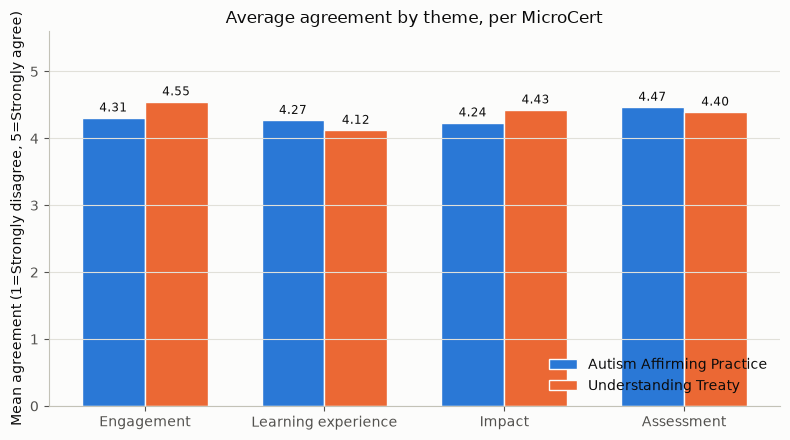

In [7]:
fig, ax = plt.subplots(figsize=(8, 4.5))
x = np.arange(len(DIMENSIONS))
width = 0.35

for i, course in enumerate(COURSES):
    vals = dim_means.loc[course].values
    offset = (i - 0.5) * width
    bars = ax.bar(x + offset, vals, width=width, color=COURSE_COLORS[course], label=course,
                   edgecolor="#fcfcfb", linewidth=1)
    for rect, v in zip(bars, vals):
        ax.text(rect.get_x() + rect.get_width() / 2, v + 0.05, f"{v:.2f}",
                 ha="center", va="bottom", fontsize=8.5)

ax.set_xticks(x)
ax.set_xticklabels(DIMENSIONS)
ax.set_ylim(0, 5.6)
ax.set_ylabel("Mean agreement (1=Strongly disagree, 5=Strongly agree)")
ax.set_title("Average agreement by theme, per MicroCert")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="x", visible=False)
ax.legend(frameon=False, loc="lower right")
fig.tight_layout()
plt.show()

## Visualisation 2 — Response distribution (diverging)

Both MicroCerts sit in one chart, grouped by theme, so you can compare them directly instead of flipping between two panels. Disagreement sits left of zero, agreement sits right, "neutral" is split evenly across the centre. Every disagree segment gets its own % label (even a thin sliver); "neutral" is left unlabelled to keep the middle uncluttered. The **% agree** / **% disagree** tags at each end are the sum of the *rounded* segment labels shown on the bar, so they always add up to what you can count on the chart yourself.

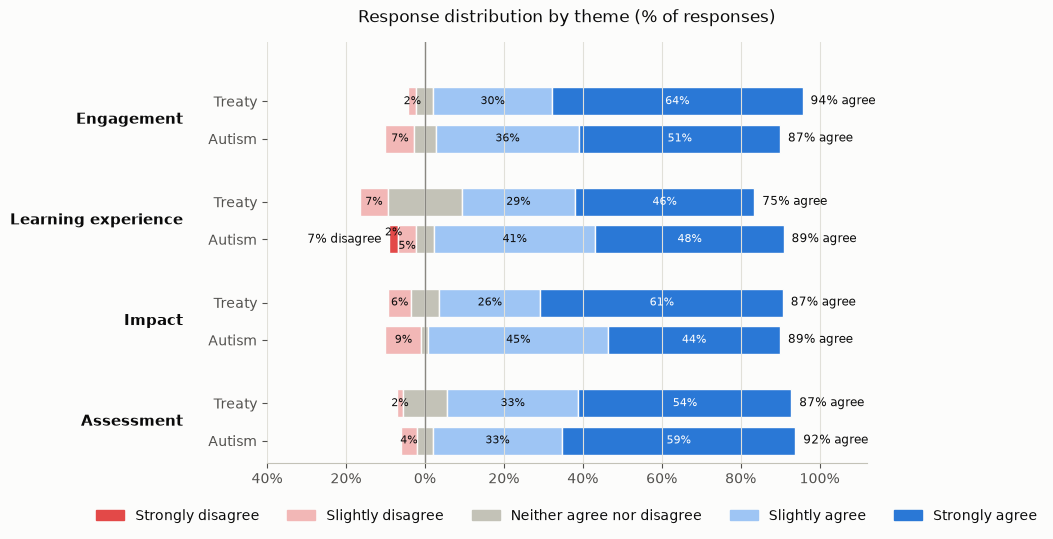

In [8]:
counts = long_df.groupby(["Course", "Dimension", "Response"]).size().unstack("Response", fill_value=0)
counts = counts.reindex(columns=LIKERT_ORDER, fill_value=0)
pct = counts.div(counts.sum(axis=1), axis=0) * 100

COURSE_SHORT = {"Autism Affirming Practice": "Autism", "Understanding Treaty": "Treaty"}
LIKERT_TEXT_COLOR = {
    "Strongly disagree": "white",
    "Slightly disagree": "#0b0b0b",
    "Neither agree nor disagree": "#0b0b0b",
    "Slightly agree": "#0b0b0b",
    "Strongly agree": "white",
}

# lay out (dimension, course) rows top-to-bottom, with an extra gap between themes
rows = []
y = 0
group_gap = 0.7
for dim in reversed(DIMENSIONS):
    for course in COURSES:
        rows.append((dim, course, y))
        y += 1
    y += group_gap

fig, ax = plt.subplots(figsize=(10, 5.5))
AGREE_LABEL_THRESHOLD = 8  # only print agree-side % labels on segments this big or bigger

for dim, course, ypos in rows:
    row = pct.loc[(course, dim)]
    # round each segment once, up front, so every downstream number (labels + end tags) matches
    sd_r, sld_r = round(row["Strongly disagree"]), round(row["Slightly disagree"])
    sla_r, sa_r = round(row["Slightly agree"]), round(row["Strongly agree"])
    neutral_half = row["Neither agree nor disagree"] / 2

    agree_label = sla_r + sa_r
    disagree_label = sd_r + sld_r
    disagree_components = sum(1 for v in (row["Strongly disagree"], row["Slightly disagree"]) if v > 0)
    # two thin disagree slivers side by side collide if both labels sit dead-centre -
    # stagger them into the top/bottom of the bar instead
    label_y_offset = {"Strongly disagree": 0.18, "Slightly disagree": -0.18} if disagree_components >= 2 else {}

    cur = -(row["Strongly disagree"] + row["Slightly disagree"] + neutral_half)
    segs = [
        ("Strongly disagree", row["Strongly disagree"], sd_r, "always"),
        ("Slightly disagree", row["Slightly disagree"], sld_r, "always"),
        ("Neither agree nor disagree", neutral_half, None, "never"),
        ("Neither agree nor disagree", neutral_half, None, "never"),
        ("Slightly agree", row["Slightly agree"], sla_r, "threshold"),
        ("Strongly agree", row["Strongly agree"], sa_r, "threshold"),
    ]
    for label, w, w_r, rule in segs:
        if w > 0:
            ax.barh(ypos, w, left=cur, height=0.75, color=LIKERT_COLORS[label],
                    edgecolor="#fcfcfb", linewidth=1)
            show = (rule == "always") or (rule == "threshold" and w >= AGREE_LABEL_THRESHOLD)
            if show:
                # a very thin sliver can't contain its own label - it overflows onto the
                # surface either side, so fall back to dark ink instead of white-on-fill
                text_color = LIKERT_TEXT_COLOR[label] if w >= 4 else "#0b0b0b"
                ax.text(cur + w / 2, ypos + label_y_offset.get(label, 0), f"{w_r:.0f}%",
                        ha="center", va="center", fontsize=8, color=text_color, clip_on=False)
        cur += w

    right_end = row["Slightly agree"] + row["Strongly agree"] + neutral_half
    left_end = -(row["Strongly disagree"] + row["Slightly disagree"] + neutral_half)
    ax.text(right_end + 2, ypos, f"{agree_label:.0f}% agree", va="center", ha="left",
            fontsize=8.5, color="#0b0b0b", clip_on=False)
    # only show the combined "X% disagree" tag when it sums two visible segments -
    # with a single disagree segment the tag would just repeat the number already on the bar
    if disagree_components >= 2:
        ax.text(left_end - 2, ypos, f"{disagree_label:.0f}% disagree", va="center", ha="right",
                fontsize=8.5, color="#0b0b0b", clip_on=False)

ax.axvline(0, color="#898781", linewidth=1)
ax.set_yticks([r[2] for r in rows])
ax.set_yticklabels([COURSE_SHORT[r[1]] for r in rows])

theme_rows = {}
for dim, course, ypos in rows:
    theme_rows.setdefault(dim, []).append(ypos)
for dim, ys in theme_rows.items():
    ax.text(-0.14, sum(ys) / len(ys), dim, transform=ax.get_yaxis_transform(),
            ha="right", va="center", fontsize=10.5, fontweight="bold", color="#0b0b0b")

# axis range follows the data's real extent (agree can run past 90%) with room for the end tags
ax.set_xlim(-40, 112)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, pos: f"{abs(v):.0f}%"))
ax.set_ylim(-0.6, y - group_gap + 0.6)
ax.spines[["top", "right", "left"]].set_visible(False)
ax.grid(axis="y", visible=False)
ax.set_title("Response distribution by theme (% of responses)", fontsize=12, pad=14)

handles = [plt.Rectangle((0, 0), 1, 1, color=LIKERT_COLORS[l]) for l in LIKERT_ORDER]
ax.legend(handles, LIKERT_ORDER, loc="upper center", ncol=5, frameon=False, bbox_to_anchor=(0.5, -0.08))
fig.tight_layout()
plt.show()

## Visualisation 3 — Net Promoter Score

Promoters (9–10), Passives (7–8) and Detractors (0–6), with the resulting NPS (Promoters % − Detractors %) for each MicroCert.

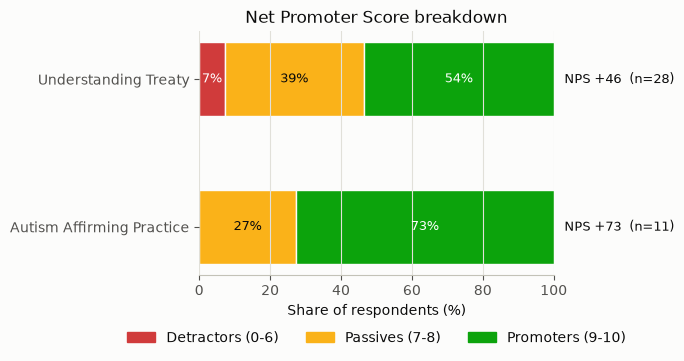

In [9]:
STATUS_COLORS = {"Promoters": "#0ca30c", "Passives": "#fab219", "Detractors": "#d03b3b"}

fig, ax = plt.subplots(figsize=(7, 3.8))
y = np.arange(len(COURSES))
for i, course in enumerate(COURSES):
    row = nps_table.loc[course]
    left = 0
    for label in ["Detractors", "Passives", "Promoters"]:
        val = row[f"{label} %"]
        ax.barh(i, val, left=left, color=STATUS_COLORS[label], height=0.5, edgecolor="#fcfcfb", linewidth=1)
        if val > 5:
            text_color = "white" if label != "Passives" else "#0b0b0b"
            ax.text(left + val / 2, i, f"{val:.0f}%", ha="center", va="center", fontsize=9, color=text_color)
        left += val
    ax.text(103, i, f"NPS {row['NPS']:+.0f}  (n={int(row['n'])})", va="center", ha="left", fontsize=9.5)

ax.set_yticks(y)
ax.set_yticklabels(COURSES)
ax.set_xlim(0, 100)
ax.set_xlabel("Share of respondents (%)")
ax.set_title("Net Promoter Score breakdown")
ax.spines[["top", "right", "left"]].set_visible(False)
ax.grid(axis="y", visible=False)
handles = [plt.Rectangle((0, 0), 1, 1, color=STATUS_COLORS[l]) for l in ["Detractors", "Passives", "Promoters"]]
ax.legend(handles, ["Detractors (0-6)", "Passives (7-8)", "Promoters (9-10)"], loc="upper center",
          bbox_to_anchor=(0.5, -0.18), ncol=3, frameon=False)
fig.tight_layout()
plt.show()

## Qualitative responses

The Likert data tells us *how much* people agreed; the open-text answers tell us *why*. Below are the non-empty responses to the "best aspects" and "areas to improve" questions for each MicroCert.

In [10]:
TEXT_QUESTIONS = {"Q6.0": "How they'll apply it", "Q7.0": "Best aspects", "Q8.0": "Areas to improve"}

for code, label in TEXT_QUESTIONS.items():
    combined = pd.concat([
        autism_df[["Course", code]].rename(columns={code: "Response"}),
        treaty_df[["Course", code]].rename(columns={code: "Response"}),
    ]).dropna(subset=["Response"]).reset_index(drop=True)
    print(f"--- {label} ({code}) ---")
    display(combined)

--- How they'll apply it (Q6.0) ---


,Course,Response
0,Autism Affirming Practice,understanding the importance of person-centred...
1,Autism Affirming Practice,Consider Autism culture
2,Autism Affirming Practice,mindful of language used and collaboration pro...
3,Autism Affirming Practice,The proactive strategies
4,Autism Affirming Practice,Neuroaffirming practice
5,Autism Affirming Practice,Through my role as a PBS practitioner
6,Autism Affirming Practice,Will utilize these skills in practice and also...
7,Autism Affirming Practice,Most especially in language used and communica...
8,Understanding Treaty,The course did not cover content that was new ...
9,Understanding Treaty,When contributing to the drafting of the new F...


--- Best aspects (Q7.0) ---


,Course,Response
0,Autism Affirming Practice,the assessments.
1,Autism Affirming Practice,Professionals in the field running the course
2,Autism Affirming Practice,engaging with other pracs / people involved in...
3,Autism Affirming Practice,The collaboration
4,Autism Affirming Practice,Assessment
5,Autism Affirming Practice,the assignments - learning and understanding
6,Autism Affirming Practice,Opportunity to network
7,Autism Affirming Practice,Hearing from living experience - Autistic prof...
8,Understanding Treaty,I cant think of anything. I felt disengaged de...
9,Understanding Treaty,The content


--- Areas to improve (Q8.0) ---


,Course,Response
0,Autism Affirming Practice,understanding that there are numerous contexts...
1,Autism Affirming Practice,The cert is designed to inform neurotypical pr...
2,Autism Affirming Practice,Communication between groups - more encouragem...
3,Autism Affirming Practice,feedback for assessment one should be provided...
4,Autism Affirming Practice,The assessments
5,Autism Affirming Practice,Group work
6,Autism Affirming Practice,group discussions
7,Autism Affirming Practice,Grades for assessment 1 (unable to see until a...
8,Autism Affirming Practice,More time or warning/sending through any readi...
9,Understanding Treaty,If your role involves presenting content on Zo...


## Word clouds

Same two questions as above (`TEXT_QUESTIONS`), but as word clouds — word size = how often it appears. Each course keeps its own colour (blue = Autism Affirming Practice, orange = Understanding Treaty) so it stays visually linked to the earlier charts. Generic filler ("nil", "course", stopwords, etc.) is stripped out first so what's left is the actual content words.

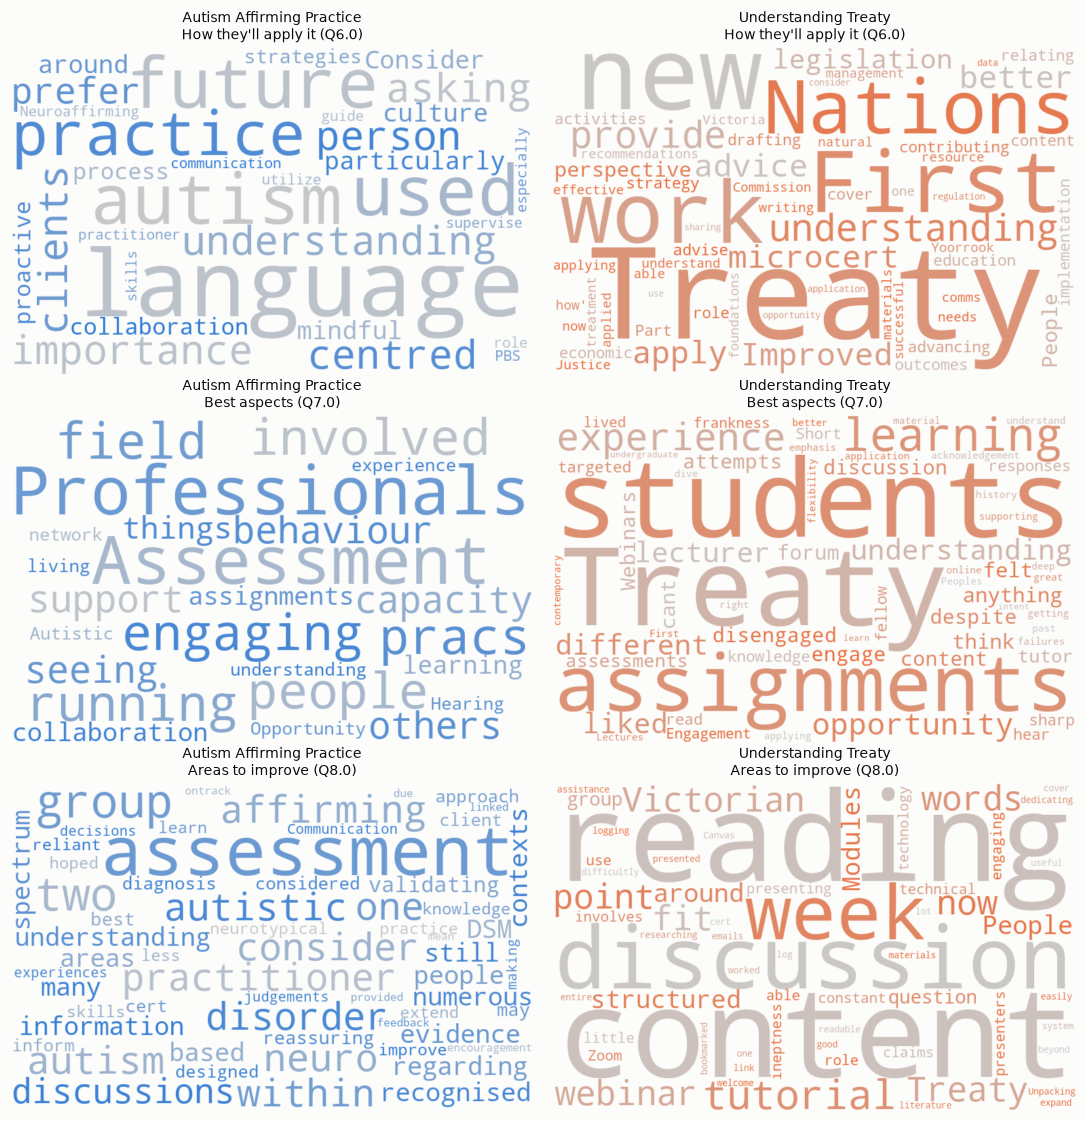

In [11]:
from wordcloud import WordCloud, STOPWORDS
from matplotlib.colors import LinearSegmentedColormap

EXTRA_STOPWORDS = {"nil", "na", "n/a", "none", "will", "course", "etc"}
STOP = STOPWORDS.union(EXTRA_STOPWORDS)

def course_colormap(hex_color):
    # single-hue sequential ramp: neutral grey -> the course's own colour
    return LinearSegmentedColormap.from_list("course", ["#c9c9c9", hex_color])

fig, axes = plt.subplots(len(TEXT_QUESTIONS), len(COURSES), figsize=(11, 3.75 * len(TEXT_QUESTIONS)))
for r, (code, label) in enumerate(TEXT_QUESTIONS.items()):
    for c, course in enumerate(COURSES):
        df = autism_df if course == COURSES[0] else treaty_df
        text = " ".join(df[code].dropna().astype(str).tolist())
        ax = axes[r, c]
        if not text.strip():
            ax.axis("off")
            continue
        wc = WordCloud(
            width=800, height=500, background_color="#fcfcfb",
            colormap=course_colormap(COURSE_COLORS[course]),
            stopwords=STOP, collocations=False, prefer_horizontal=0.95,
            max_words=60, random_state=42,
        ).generate(text)
        ax.imshow(wc, interpolation="bilinear")
        ax.axis("off")
        ax.set_title(f"{course}\n{label} ({code})", fontsize=10)

fig.tight_layout()
plt.show()